In [1]:
import sys
sys.path.append("../src")

In [2]:
from Database import MONGO_COLLECTION, MONGO_DB, MONGO_URI
from pymongo import MongoClient
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from preprocessing import spam,clean,stopword

In [3]:
class index:
    def __init__(self):
        self.database()
    def database(self):
        client = MongoClient(MONGO_URI)
        db = client[MONGO_DB]
        self.collection = db[MONGO_COLLECTION]
    def data(self):
        datastore = list(self.collection.find())
        return datastore
if __name__ =="__main__":
    app = index()
    data = app.data()
    df = pd.DataFrame(data)
    data = df.to_dict('records')

In [4]:
content =[]
for i in data:
    content.append(str(i.get('content', "")))


In [5]:
cleaned_content = [clean(item) for item in content]

In [6]:
cleaned_content

['bộ phim tuyên truyền chủ nghĩa dân tộc cực đoan mưa đỏ aka máu kinh đang được truyền thông dư luận viên bò đỏ sô vanh con tung hê hết lời phim hiện đã thu về 28 tỷ đồng vào ngày đầu công chiếu là hôm nay nhờ huy động đoàn viên thanh niên và cán bộ công nhân viên chức ra rạp xem cũng như cắt sạch suất chiếu giờ đẹp của các bộ phim nước ngoài trong đó có cả bộ phim anime ăn khách thanh gươm diệt quỷ vô hạn thành không chỉ tuyên truyền tuyên giáo còn chỉ thị cho nhóm reviewer báo chí lên bài dìm hàng các bộ phim nước ngoài không phải tự nhiên mà càng đến gần ngày phim mưa đỏ công chiếu thì tần suất các bài viết video dìm hàng vô hạn thành xuất hiện dày đặc hơn tôi đéo quan tâm cái phim mưa đỏ nó có nội dung nhân văn hay có cái coin card gì trong đó tôi chỉ biết nó là một bộ phim chiến tranh tuyên truyền chống mỹ giống như hàng vạn bộ phim mà các hãng phim cộng sản xứ này sản xuất trước đây chấm hết rfa và voa có lẽ giờ đã thấy hối hận khi ngày xưa lỡ viết bài tâng bốc lâm hưng yên là ng

In [7]:
content

['Bộ phim tuyên truyền chủ nghĩa dân tộc cực đoan Mưa Đỏ aka Máu Kinh đang được truyền thông, dư luận viên, bò đỏ, Sô-Vanh con tung hê hết lời. Phim hiện đã thu về 28 tỷ đồng vào ngày đầu công chiếu là hôm nay, nhờ huy động đoàn viên thanh niên và cán bộ công nhân viên chức ra rạp xem, cũng như cắt sạch suất chiếu giờ đẹp của các bộ phim nước ngoài trong đó có cả bộ phim anime ăn khách Thanh Gươm Diệt Quỷ: Vô Hạn Thành. \n\nKhông chỉ tuyên truyền, Tuyên Giáo còn chỉ thị cho nhóm reviewer, báo chí lên bài dìm hàng các bộ phim nước ngoài. Không phải tự nhiên mà càng đến gần ngày phim Mưa Đỏ công chiếu thì tần suất các bài viết, video "dìm hàng" Vô Hạn Thành xuất hiện dày đặc hơn. \n\nTôi đéo quan tâm cái phim Mưa Đỏ nó có nội dung nhân văn hay có cái coin card gì trong đó. Tôi chỉ biết nó là một bộ phim chiến tranh tuyên truyền chống Mỹ, giống như hàng vạn bộ phim mà các hãng phim Cộng Sản xứ này sản xuất trước đây, chấm hết. \n\nRFA và VOA có lẽ giờ đã thấy hối hận khi ngày xưa lỡ viết 

In [8]:
remove_stopwords = stopword(cleaned_content)

In [9]:
remove_stopwords

['phim tuyên truyền nghĩa dân tộc đoan mưa đỏ aka máu kinh truyền thông viên bò đỏ sô vanh tung phim 28 tỷ chiếu động đoàn viên niên cán viên chức rạp sạch suất chiếu đẹp phim phim anime gươm diệt quỷ tuyên truyền tuyên giáo reviewer báo dìm hàng phim phim mưa đỏ chiếu suất viết video dìm hàng dày đéo phim mưa đỏ nội dung coin card phim chiến tranh tuyên truyền chống mỹ hàng phim hãng phim cộng sản xứ sản chấm rfa voa hối lỡ viết tâng bốc lâm yên thoát giáo cộng sản sẵn sàng thoát trump ngân sách oan việt nam quốc phiên 2 nghĩa dân tộc đoan che đậy thất bại kinh giáo dục phát triển quốc cường phim chống nhật việt nam chước phim chống mỹ chống pháp quốc sản phim gameshow tâng bốc quân đội lính cứu hỏa vn chước hệt quốc xây dựng đội ngũ truyền thông sâu rộng kích nghĩa tây việt nam tận bọn kol nổi tiếng tương thoát thù địch giới phát triển thẩm sướng dân quốc đám đáy giếng sủa phá hoại phát triển dây dưa thằng tàu sách thuế chống quốc trump tàu cộng sâu bọn việt nam thẩm hào dân tộc giúp

<Axes: xlabel='author'>

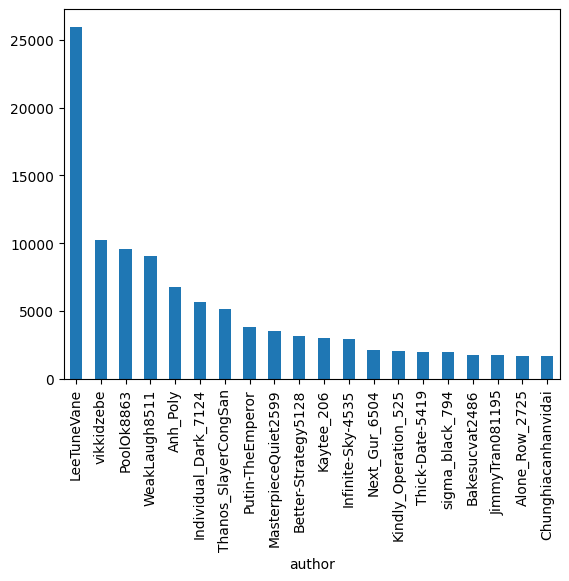

In [10]:
df.groupby('author')['upvotes'].sum().nlargest(20).plot(kind='bar')


<Axes: xlabel='author'>

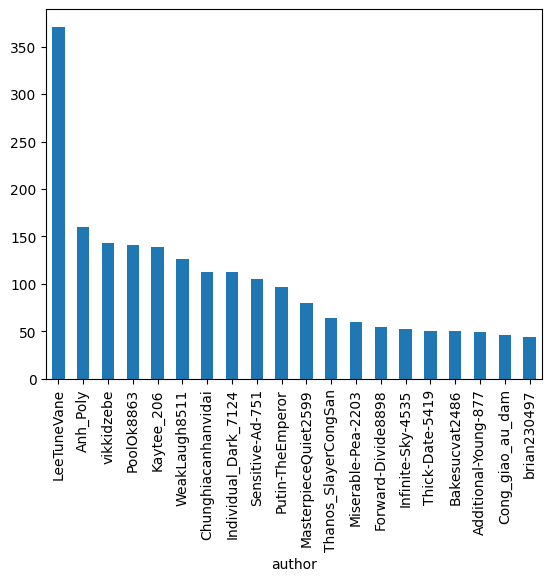

In [11]:
df['author'].value_counts().head(20).plot(kind='bar')

<Axes: xlabel='date'>

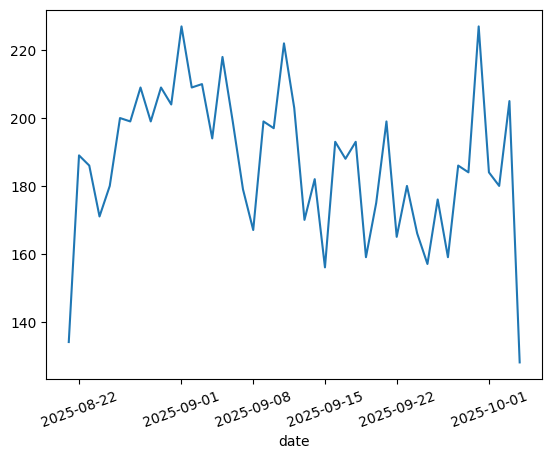

In [12]:
df['date'] = pd.to_datetime(df['date'])
df.groupby(df['date'].dt.date).size().plot(kind='line', rot=20)


<Axes: xlabel='subreddit'>

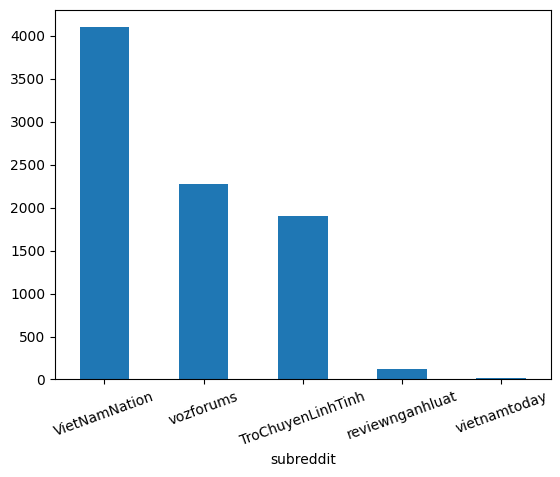

In [13]:
df['subreddit'].value_counts().plot(kind='bar', rot=20)

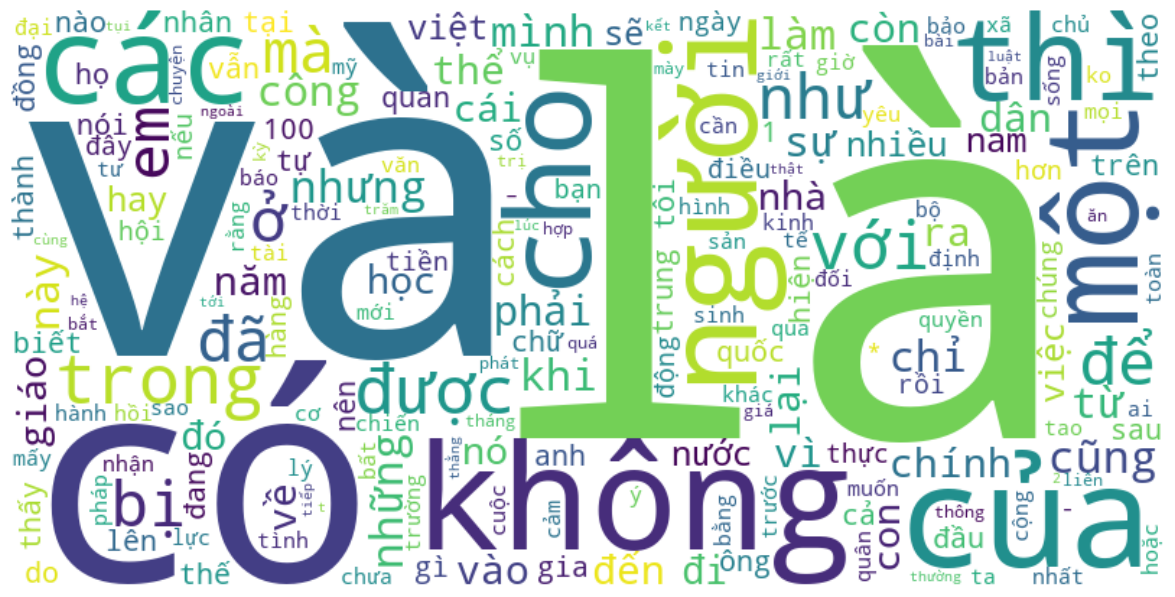

In [14]:
all_text = ' '.join(df['content'].dropna().astype(str))
words = all_text.lower().split()
word_counts = Counter(words)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

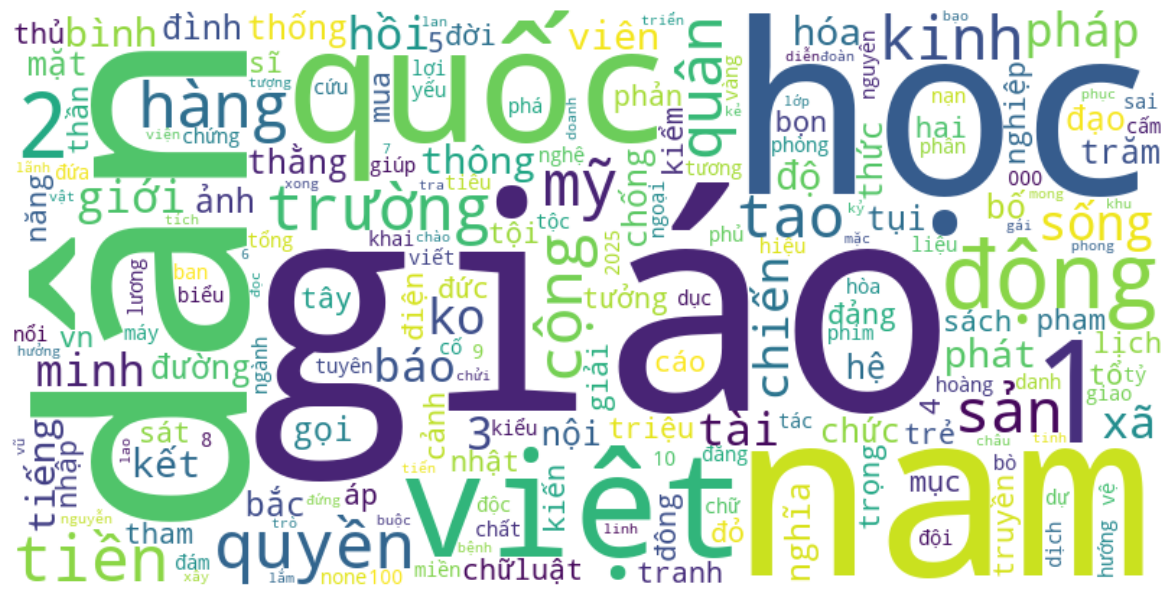

In [71]:

all_text = " ".join(remove_stopwords)
words = all_text.lower().split()
word_counts = Counter(words)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()